# 03 - Exploratory Data Analysis (Grant Witness)
data source: grant-witness.us

## Imports

In [24]:
# imports
import pandas as pd
import re
import os
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

import torch
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import seaborn as sns
import matplotlib.pyplot as plt


In [25]:
df_epa = pd.read_csv('00_data/df_epa.csv')
df_nih = pd.read_csv('00_data/df_nih.csv')
df_nsf = pd.read_csv('00_data/df_nsf.csv')
df_samhsa = pd.read_csv('00_data/df_samhsa.csv')
df_cdc = pd.read_csv('00_data/df_cdc.csv')


In [26]:
dfs = {'nih': df_nih, 'nsf': df_nsf, 'epa': df_epa, 'samhsa': df_samhsa}
dfs_titles = {'nih': df_nih, 'nsf': df_nsf, 'epa': df_epa, 'samhsa': df_samhsa, 'cdc': df_cdc}

In [28]:
for name, df in dfs.items():
    data = np.load(f'embeddings/{name}_abstract_allminilm.npz', allow_pickle=True)

    embed_ids = pd.Series(data['grant_id']).map(lambda x: x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x).astype(str).str.strip()

    embed_df = pd.DataFrame({'grant_id': embed_ids, 'embeddings_abstract_allminilm': list(data['embeddings'])})

    df = df.copy()
    df['grant_id'] = df['grant_id'].astype(str).str.strip()

    df = df.drop(columns=[c for c in df.columns if c.startswith('embeddings_abstract_allminilm')], errors='ignore')

    df = df.merge(embed_df, on='grant_id', how='left')
    dfs[name] = df

    print(name)
    print('  has embeddings column:', 'embeddings_abstract_allminilm' in df.columns)
    print('  missing embeddings share:', round(df['embeddings_abstract_allminilm'].isna().mean(), 4))

# CDC has no abstract embeddings — add empty column and include in dfs
df_cdc = df_cdc.copy()
df_cdc['embeddings_abstract_allminilm'] = None
df_cdc['abstract'] = None
dfs['cdc'] = df_cdc

df_nih, df_nsf, df_epa, df_samhsa, df_cdc = dfs['nih'], dfs['nsf'], dfs['epa'], dfs['samhsa'], dfs['cdc']

nih
  has embeddings column: True
  missing embeddings share: 0.0
nsf
  has embeddings column: True
  missing embeddings share: 0.0
epa
  has embeddings column: True
  missing embeddings share: 0.0
samhsa
  has embeddings column: True
  missing embeddings share: 0.0


In [30]:
def add_title_embeddings(dfs):
    for name, df in dfs.items():
        data = np.load(f'embeddings/{name}_project_title_allminilm.npz', allow_pickle=True)

        embed_ids = pd.Series(data['grant_id']).map(lambda x: x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x).astype(str).str.strip()

        embed_df = pd.DataFrame({'grant_id': embed_ids, 'embeddings_title_allminilm': list(data['embeddings'])})

        df = df.copy()
        df['grant_id'] = df['grant_id'].astype(str).str.strip()

        df = df.drop(columns=[c for c in df.columns if c.startswith('embeddings_title_allminilm')], errors='ignore')

        df = df.merge(embed_df, on='grant_id', how='left')
        dfs[name] = df

        print(name)
        print('  has title embeddings column:', 'embeddings_title_allminilm' in df.columns)
        print('  missing title embeddings share:', round(df['embeddings_title_allminilm'].isna().mean(), 4))

add_title_embeddings(dfs)

df_nih, df_nsf, df_epa, df_samhsa, df_cdc = dfs['nih'], dfs['nsf'], dfs['epa'], dfs['samhsa'], dfs['cdc']

nih
  has title embeddings column: True
  missing title embeddings share: 0.0
nsf
  has title embeddings column: True
  missing title embeddings share: 0.0
epa
  has title embeddings column: True
  missing title embeddings share: 0.0
samhsa
  has title embeddings column: True
  missing title embeddings share: 0.0
cdc
  has title embeddings column: True
  missing title embeddings share: 0.0


Combining into one df

In [33]:
for name, df in dfs.items():
    print(name, 'embeddings_title_allminilm' in df.columns)

nih True
nsf True
epa True
samhsa True
cdc True


In [34]:
dfs
common_cols = sorted(set.intersection(*(set(df.columns) for df in dfs.values())))

dfs_common = {name: df[common_cols].copy() for name, df in dfs.items()}

df_all_common = pd.concat(dfs_common.values(), ignore_index=True)

df_all_common = df_all_common.drop(columns=["Unnamed: 0"], errors="ignore")

In [35]:
df_all_common.columns


Index(['abstract', 'agency', 'award_amount', 'award_outlaid',
       'award_remaining', 'embeddings_abstract_allminilm',
       'embeddings_title_allminilm', 'flagged_words_all',
       'flagged_words_all_title', 'flagged_words_nyt',
       'flagged_words_nyt_title', 'flagged_words_pen',
       'flagged_words_pen_title', 'grant_id', 'has_flagged_word',
       'has_flagged_word_title', 'has_flagged_word_total', 'n_banned_terms',
       'n_banned_terms_title', 'n_banned_terms_total', 'num_flagged_words',
       'num_flagged_words_title', 'num_flagged_words_total', 'num_nyt_words',
       'num_nyt_words_title', 'num_nyt_words_total', 'num_pen_words',
       'num_pen_words_title', 'num_pen_words_total', 'org_city', 'org_name',
       'org_state', 'project_title', 'reinstatement_date',
       'reinstatement_indicator', 'start_date_original', 'status',
       'termination_date', 'usaspending_url'],
      dtype='object')

## Overview of dfs

In [36]:
dfs['all'] = df_all_common
dfs.keys()

dict_keys(['nih', 'nsf', 'epa', 'samhsa', 'cdc', 'all'])

In [12]:
for name, df in dfs.items():
    print(f"\n{name}")
    print("rows:", len(df))
    print("columns:", len(df.columns))
    if 'abstract' in df.columns:
        print("missing abstracts:", df["abstract"].isna().sum())
        print("missing abstracts:", df["abstract"].isna().mean())


nih
rows: 6300
columns: 74
missing abstracts: 30
missing abstracts: 0.004761904761904762

nsf
rows: 1996
columns: 58
missing abstracts: 5
missing abstracts: 0.00250501002004008

epa
rows: 671
columns: 48
missing abstracts: 0
missing abstracts: 0.0

samhsa
rows: 2931
columns: 50
missing abstracts: 262
missing abstracts: 0.08938928693278744

cdc
rows: 542
columns: 56
missing abstracts: 542
missing abstracts: 1.0

all
rows: 12032
columns: 30


Dropping missing abstracts

In [ ]:
for name in dfs:
    if 'abstract' in df.columns:
        dfs[name] = dfs[name].dropna(subset=["abstract"])
        dfs[name] = dfs[name][dfs[name]["abstract"].astype(str).str.strip() != ""]

### Status options

In [ ]:
status_counts = {}

for name, df in dfs.items():
    status_counts[name] = df['status'].value_counts()

counts_df = pd.DataFrame(status_counts).fillna(0)

counts_df = counts_df.sort_index()

In [ ]:
counts_df

In [ ]:
color_map = {
    "Terminated": "black",
    "Frozen Funding": "#4d4d4d",              # dark grey
    "Possibly Unfrozen Funding": "#9ecae1",   # light blue
    "Unfrozen Funding": "#3182bd",            # stronger blue
    "Possibly Reinstated": "#a1d99b",         # light green
    "Reinstated": "#006d2c",                  # dark saturated green (best outcome)
}

status_order = [
    "Terminated",
    "Frozen Funding",
    "Possibly Unfrozen Funding",
    "Unfrozen Funding",
    "Possibly Reinstated",
    "Reinstated",
]

wrapped_labels = {
    "Terminated": "Terminated",
    "Frozen Funding": "Frozen\nFunding",
    "Possibly Unfrozen Funding": "Possibly\nUnfrozen\nFunding",
    "Unfrozen Funding": "Unfrozen\nFunding",
    "Possibly Reinstated": "Possibly\nReinstated",
    "Reinstated": "Reinstated"
}

In [ ]:
counts_df = counts_df.reindex(status_order).fillna(0)

colors = [color_map[s] for s in counts_df.index]

In [ ]:
sns.set_style("whitegrid")

relative_df = counts_df.div(counts_df.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(3, 2.5))

bottom = pd.Series(0, index=relative_df.columns)

for status in relative_df.index:
    values = relative_df.loc[status]
    ax.bar(relative_df.columns, values,
           bottom=bottom,
           color=color_map[status],
           label=wrapped_labels[status])
    bottom += values

ax.set_ylabel("Proportion")
ax.set_xlabel("Agency")
ax.set_title("")

ax.legend(
    title="Status",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=6,
    title_fontsize=6
)

plt.tight_layout()

plt.show()

In [ ]:
fig, ax = plt.subplots()

bottom = None

for status in counts_df.index:
    values = counts_df.loc[status]
    
    if bottom is None:
        ax.bar(counts_df.columns, values,
               color=color_map[status],
               label=status)
        bottom = values
    else:
        ax.bar(counts_df.columns, values,
               bottom=bottom,
               color=color_map[status],
               label=status)
        bottom += values

ax.set_ylabel("Number of Grants")
ax.set_xlabel("Agency")
ax.set_title("Grant Status Counts by Agency")
ax.legend(title="Status", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Do grants with flagged words get terminated more often?

In [ ]:
df_all_common.groupby('status')['num_flagged_words'].mean()

In [ ]:
df_all_common.groupby('status')['num_flagged_words_title'].mean()

## Overview of abstracts

How are abstracts distributed? What is the quality of data?

In [ ]:
def add_word_count(df):
    df['abstract_word_count'] = (
        df['abstract']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )
    return df

df_nih = add_word_count(df_nih)
df_epa = add_word_count(df_epa)
df_nsf = add_word_count(df_nsf)
df_samhsa = add_word_count(df_samhsa)

df_all_common = add_word_count(df_all_common)
df_all_common['abstract_word_count'].describe()

In [ ]:
def add_word_count(df):
    df['title_word_count'] = (
        df['project_title']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )
    return df

df_nih = add_word_count(df_nih)
df_epa = add_word_count(df_epa)
df_nsf = add_word_count(df_nsf)
df_samhsa = add_word_count(df_samhsa)

df_all_common = add_word_count(df_all_common)
df_all_common['title_word_count'].describe()

In [ ]:
df_all_common['abstract_word_count'].describe()

In [ ]:
df_all_common['title_word_count'].describe()

Overview per agency: what % of abstracts has flagged words and what is avg length of abstracts?

In [ ]:
summary = pd.DataFrame([
    {
        'agency': name,
        'rows': len(df),
        'pct_flagged': df['has_flagged_word'].mean(),
        'avg_abstract_len': df['abstract_word_count'].mean()
    }
    for name, df in dfs.items()
])

summary

Average flagged words breakdown per agency

In [ ]:
summary = pd.DataFrame([
    {
        "agency": name,
        "rows": len(df),
        "pct_flagged": df["has_flagged_word"].mean(),
        "avg_flagged_words": df["num_flagged_words"].mean(),
        "avg_flagged_words_title": df["num_flagged_words_title"].mean(),
        "avg_pen_words": df["num_pen_words"].mean(),
        "avg_nyt_words": df["num_nyt_words"].mean()
    }
    for name, df in dfs.items()
])

summary

In [ ]:
for name, df in dfs.items():
    print(f'\n{name}')
    print('Has flagged word:', df['has_flagged_word'].mean())
    print('Avg # flagged words:', df['num_flagged_words'].mean())
    print('Has flagged word in title:', df['has_flagged_word_title'].mean())
    print('Avg # flagged words in title:', df['num_flagged_words_title'].mean())

NIH-specific check - is there overlap between words already flagged and PEN&NYT?

In [ ]:
df_nih[['flagged_words', 'flagged_words_pen', 'flagged_words_nyt', 'flagged_words_all', 'num_flagged_words']].head(20)

In [ ]:
(df_nih['flagged_words'].notna()).mean()

In [ ]:
(df_nih['flagged_words_all'] != '').mean()

Largely yes, original flagged_words has more coverage than the PAN/NYT lists.

### Checking duplicate abstracts

In [37]:
df_all_common["abstract"].value_counts().head(10)

abstract
DESCRIPTION:NOTE: A SPECIAL PAYMENT CONDITION APPLIES TO THIS AWARD.\n\nTHIS AGREEMENT PROVIDES FUNDING UNDER THE INFLATION REDUCTION ACT. THE RECIPIENT WILL PROVIDE FINANCIAL AND TECHNICAL ASSISTANCE TO LOW-INCOME AND DISADVANTAGED COMMUNITIES TO DEPLOY AND BENEFIT FROM RESIDENTIAL-SERVING DISTRIBUTED SOLAR ENERGY AND STORAGE PROJECTS. THESE PROGRAMS WILL ENSURE LOW-INCOME HOUSEHOLDS RECEIVE RESIDENTIAL DISTRIBUTED SOLAR BY PROVIDING PROGRAM BENEFICIARIES HOUSEHOLD SAVINGS, COMMUNITY OWNERSHIP, ENERGY RESILIENCE, AND OTHER MEANINGFUL BENEFITS.\nACTIVITIES:SOLAR PROJECTS RECEIVING FINANCIAL ASSISTANCE FROM THE RECIPIENT MAY RECEIVE ASSISTANCE FOR ASSOCIATED ENERGY STORAGE AND UPGRADES THAT EITHER ENABLE PROJECT DEPLOYMENT OR MAXIMIZE THE BENEFITS OF THE PROJECT FOR LOW-INCOME AND DISADVANTAGED COMMUNITIES. THE RECIPIENT WILL ALSO PROVIDE PROJECT-DEPLOYMENT SERVICES TO ENABLE LOW-INCOME AND DISADVANTAGED COMMUNITIES TO DEPLOY AND BENEFIT FROM RESIDENTIAL SOLAR.SUBRECIPIENT:NO S

Binary adverse outcome var

In [38]:
df_all_common["status"].value_counts(normalize=True)

status
Possibly Reinstated          0.496792
Terminated                   0.293024
Unfrozen Funding             0.091231
Possibly Unfrozen Funding    0.078315
Reinstated                   0.022211
Frozen Funding               0.012915
At-risk                      0.005512
Name: proportion, dtype: float64

In [39]:
adverse_statuses = ['Terminated', 'Frozen Funding']

df_all_common['target_adverse'] = df_all_common['status'].isin(adverse_statuses).astype(int)

In [40]:
df_all_common["target_adverse"].value_counts(normalize=True)

target_adverse
0    0.694061
1    0.305939
Name: proportion, dtype: float64

In [42]:
df_all_common.to_csv('00_data/df_full.csv')

## Embeddings analysis

Norms

In [45]:
for name, df in dfs.items():
    if 'embeddings_abstract_allminilm' in df.columns:
        non_null = df['embeddings_abstract_allminilm'].dropna()
        if non_null.empty:
            continue
        norms = np.linalg.norm(np.vstack(non_null.tolist()), axis=1)
        print(name, norms.min(), norms.mean(), norms.max())


nih 0.9999999 1.0 1.0000001
nsf 0.99999994 1.0 1.0000001
epa 0.99999994 1.0 1.0000001
samhsa 0.9999999 1.0 1.0000001
all 0.9999999 1.0 1.0000001


## PCA

In [47]:
df_nona = df_all_common[df_all_common['abstract'].notna()]
df_nona

,abstract,agency,award_amount,award_outlaid,award_remaining,embeddings_abstract_allminilm,embeddings_title_allminilm,flagged_words_all,flagged_words_all_title,flagged_words_nyt,...,org_name,org_state,project_title,reinstatement_date,reinstatement_indicator,start_date_original,status,termination_date,usaspending_url,target_adverse
3,PROJECT SUMMARY This institutional grant propo...,NIH,8000000.00,8000000.00,0.00,"[-0.074672185, -0.016338319, -0.08393002, -0.0...","[0.028941378, -0.009007949, -0.11770269, -0.05...",institutional; trans,institutional,institutional,...,COLUMBIA UNIVERSITY HEALTH SCIENCES,NY,Creation of an Institutional Biobanking Facility,2025-04-11,Removed from TAGGS list,NaN,Possibly Reinstated,2025-03-12,https://www.usaspending.gov/award/ASST_NON_C06...,0
4,Project Summary/Abstract Wards 7 and 8 in Wash...,NIH,2000000.00,618137.31,1381862.69,"[-0.012983461, 0.0211151, -0.0103896, -0.01310...","[-0.0071374844, -0.0019247083, -0.019474044, -...",community; inequities; integration; marginaliz...,community,inequities; marginalized; racial; socioeconomi...,...,"WHITMAN-WALKER INSTITUTE, INC.",DC,Developing a Community-Based Facility to Suppo...,2025-08-08,Removed from TAGGS list,NaN,Possibly Reinstated,2025-03-21,https://www.usaspending.gov/award/ASST_NON_C06...,0
5,Project Summary The goal of the proposed HIV/...,NIH,113750.86,113750.86,0.00,"[-0.020259788, 0.070057325, 1.1394546e-05, 0.0...","[0.01626549, 0.081339285, -0.024191506, 0.0371...",barrier; barriers; bipoc; black; community; co...,NaN,barriers; bipoc; black; historically; inequiti...,...,MEHARRY MEDICAL COLLEGE,TN,Meharry HIV/AIDS Research and Training Facility,NaN,NaN,NaN,Terminated,2025-03-21,https://www.usaspending.gov/award/ASST_NON_C06...,1
7,PROJECT SUMMARY The Northwestern University (N...,NIH,1302310.00,933861.02,368448.98,"[-0.030403694, 0.016826417, -0.06393584, -0.00...","[0.017131364, 0.08827437, -0.021745682, -0.030...",NaN,NaN,NaN,...,NORTHWESTERN UNIVERSITY AT CHICAGO,IL,Infection-Associated Cancer Research Training ...,NaN,NaN,2025-04-08,Possibly Unfrozen Funding,NaN,https://www.usaspending.gov/award/ASST_NON_D43...,0
8,Project Summary/Abstract HIV-related brain dis...,NIH,3643159.00,830968.51,2812190.49,"[-0.020096771, -0.0061126766, -0.04396522, -0....","[-0.026688209, 0.029015489, -0.041914828, -0.0...",at risk; gender; mental health; minority; sex;...,NaN,at risk; gender; mental health; minority,...,NORTHWESTERN UNIVERSITY AT CHICAGO,IL,Multidisciplinary NeuroAIDS Research and Train...,NaN,NaN,2025-04-08,Possibly Unfrozen Funding,NaN,https://www.usaspending.gov/award/ASST_NON_D43...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11583,The Gay and Lesbian Community Center of Southe...,SAMHSA,1399951.00,627976.17,771974.83,"[0.008934985, 0.0107743265, -0.1016433, 0.0558...","[0.03970274, 0.034464035, 0.010691343, 0.02728...",at risk; black; community; female; gay; gender...,minority,at risk; black; female; gender; men who have s...,...,GAY AND LESBIAN COMMUNITY CENTER OF SOUTHERN N...,NV,Minority AIDS Initiative: Substance Use Disord...,2026-01-14,Other reporting,2024-09-30,Possibly Reinstated,2026-01-13,https://www.usaspending.gov/award/ASST_NON_H79...,0
11584,The American Academy of Addiction Psychiatry (...,SAMHSA,37000000.00,9429793.33,27570206.67,"[-0.0023511848, -0.0378925, -0.02711254, 0.046...","[-0.045401487, 0.053017233, -0.033594124, 0.06...",black; community; continuum; culturally respon...,tribal,black; culturally responsive; diverse; diverse...,...,AMERICAN ACADEMY OF ADDICTION PSYCHIATRY,RI,State Opioid Response (SOR)/Tribal Opioid Resp...,2026-01-14,Other reporting,2024-09-30,Possibly Reinstated,2026-01-13,https://www.usaspending.gov/award/ASST_NON_H79...,0
11585,"The Ali Forney Center (AFC), the largest provi...",SAMHSA,1399980.00,358000.00,1041980.00,"[0.04610798, -0.027305817, -0.07742216, 0.0032...","[0.03970274, 0.034464035, 0.010691343, 0.02728...",bipoc; bisexual; black;

Abstract explained variance: [0.09853885 0.0544432  0.02969697 0.02728721 0.02540504 0.01923179
 0.0180938  0.01735319 0.01475004 0.01411157]
Title explained variance: [0.08093011 0.04519858 0.03380673 0.02650907 0.02514001 0.02180462
 0.0207096  0.01746957 0.01642584 0.01510744]


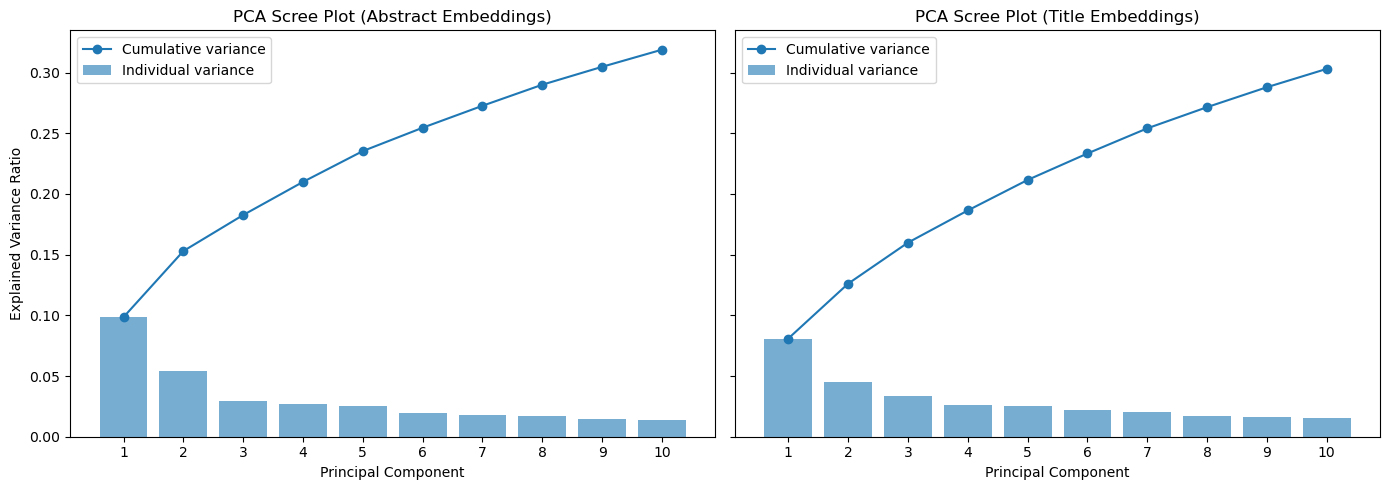

In [48]:
# Prepare matrices
X_abs = np.vstack(df_nona['embeddings_abstract_allminilm'].tolist())
X_title = np.vstack(df_nona['embeddings_title_allminilm'].tolist())

# PCA
pca_abs = PCA(n_components=10)
X_abs_pca = pca_abs.fit_transform(X_abs)

pca_title = PCA(n_components=10)
X_title_pca = pca_title.fit_transform(X_title)

print("Abstract explained variance:", pca_abs.explained_variance_ratio_)
print("Title explained variance:", pca_title.explained_variance_ratio_)

# Variance values
explained_abs = pca_abs.explained_variance_ratio_
cum_abs = np.cumsum(explained_abs)

explained_title = pca_title.explained_variance_ratio_
cum_title = np.cumsum(explained_title)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Abstract plot
axes[0].bar(range(1, len(explained_abs)+1), explained_abs, alpha=0.6, label='Individual variance')
axes[0].plot(range(1, len(explained_abs)+1), cum_abs, marker='o', label='Cumulative variance')
axes[0].set_title('PCA Scree Plot (Abstract Embeddings)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, len(explained_abs)+1))
axes[0].legend()

# Title plot
axes[1].bar(range(1, len(explained_title)+1), explained_title, alpha=0.6, label='Individual variance')
axes[1].plot(range(1, len(explained_title)+1), cum_title, marker='o', label='Cumulative variance')
axes[1].set_title('PCA Scree Plot (Title Embeddings)')
axes[1].set_xlabel('Principal Component')
axes[1].set_xticks(range(1, len(explained_title)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

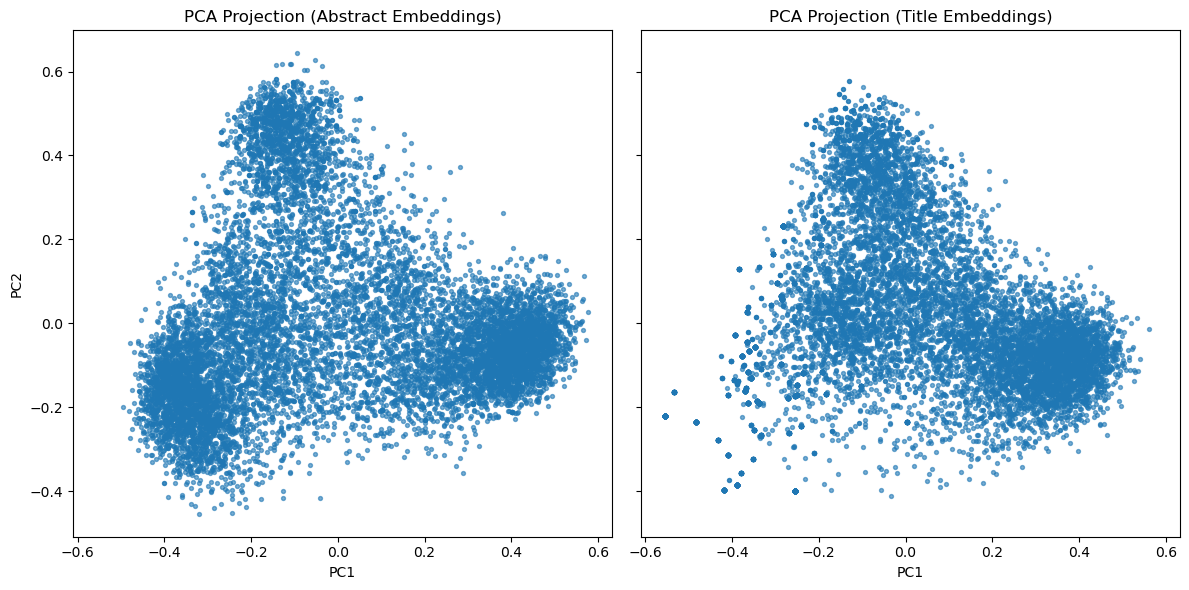

In [49]:
# PCA for abstract embeddings
X_abs = np.vstack(df_nona['embeddings_abstract_allminilm'].tolist())
pca_abs = PCA(n_components=10)
X_abs_pca = pca_abs.fit_transform(X_abs)

# PCA for title embeddings
X_title = np.vstack(df_nona['embeddings_title_allminilm'].tolist())
pca_title = PCA(n_components=10)
X_title_pca = pca_title.fit_transform(X_title)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Abstract PCA scatter
axes[0].scatter(X_abs_pca[:, 0], X_abs_pca[:, 1], s=8, alpha=0.6)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection (Abstract Embeddings)")

# Title PCA scatter
axes[1].scatter(X_title_pca[:, 0], X_title_pca[:, 1], s=8, alpha=0.6)
axes[1].set_xlabel("PC1")
axes[1].set_title("PCA Projection (Title Embeddings)")

plt.tight_layout()
plt.show()

By adverse outcome binary

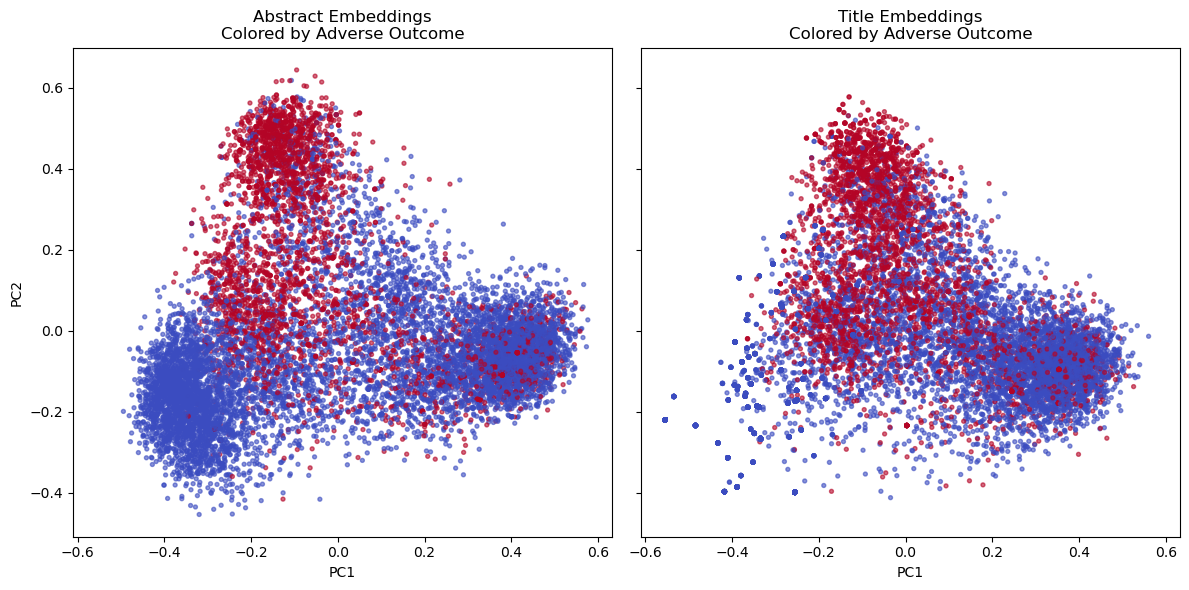

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Abstract embeddings
axes[0].scatter(
    X_abs_pca[:, 0],
    X_abs_pca[:, 1],
    c=df_nona['target_adverse'],
    cmap='coolwarm',
    s=8,
    alpha=0.6
)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Abstract Embeddings\nColored by Adverse Outcome')

# Title embeddings
scatter = axes[1].scatter(
    X_title_pca[:, 0],
    X_title_pca[:, 1],
    c=df_nona['target_adverse'],
    cmap='coolwarm',
    s=8,
    alpha=0.6
)

axes[1].set_xlabel('PC1')
axes[1].set_title('Title Embeddings\nColored by Adverse Outcome')


plt.tight_layout()
plt.show()

By status

/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_73965/1860503043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nona["status"] = df_nona["status"].astype("category")


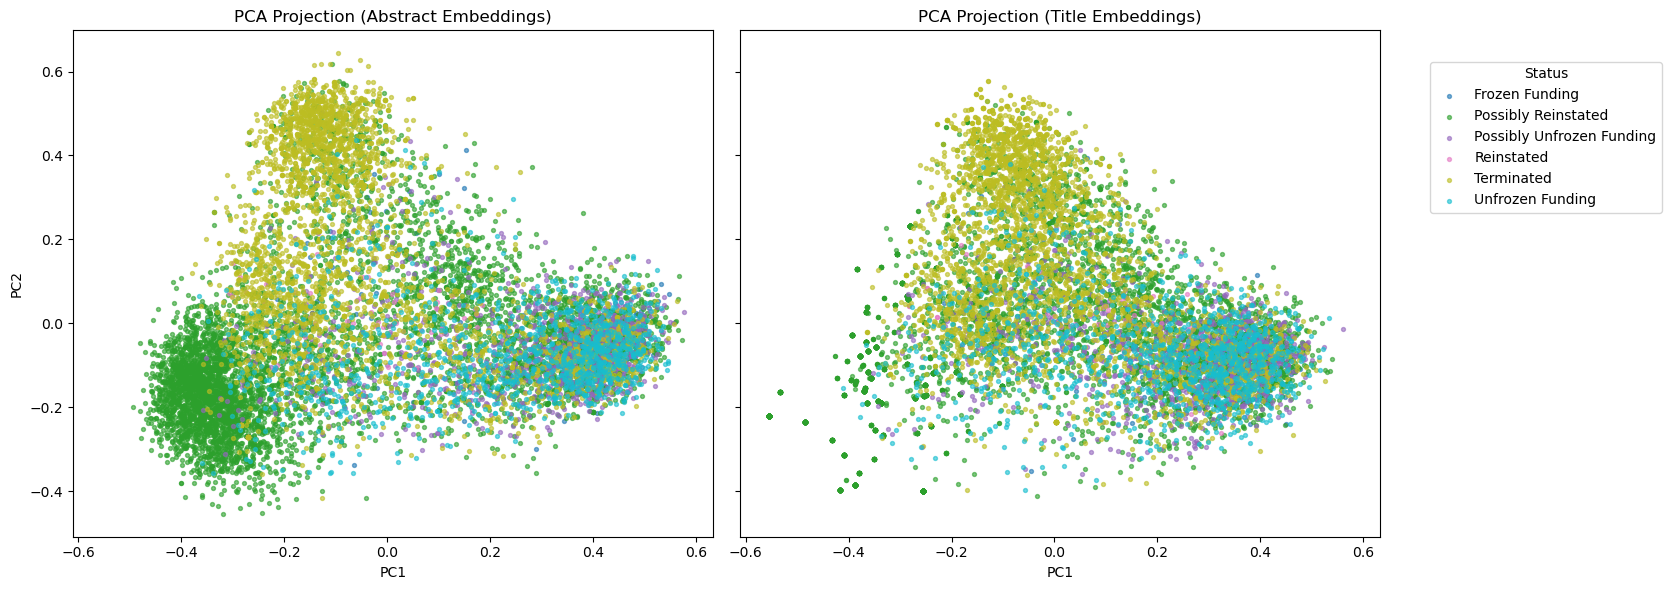

In [53]:
# Ensure categorical
df_nona["status"] = df_nona["status"].astype("category")

statuses = df_nona["status"].cat.categories

# Generate colors
colors = plt.cm.tab10(np.linspace(0, 1, len(statuses)))
color_dict = dict(zip(statuses, colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Abstract embeddings ---
for status in statuses:
    mask = df_nona["status"] == status
    axes[0].scatter(
        X_abs_pca[mask, 0],
        X_abs_pca[mask, 1],
        label=status,
        color=color_dict[status],
        s=8,
        alpha=0.6
    )

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection (Abstract Embeddings)")

# --- Title embeddings ---
for status in statuses:
    mask = df_nona["status"] == status
    axes[1].scatter(
        X_title_pca[mask, 0],
        X_title_pca[mask, 1],
        label=status,
        color=color_dict[status],
        s=8,
        alpha=0.6
    )

axes[1].set_xlabel("PC1")
axes[1].set_title("PCA Projection (Title Embeddings)")

# Shared legend on the side
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Status", bbox_to_anchor=(1.02, 0.9), loc="upper left")

plt.tight_layout()
plt.show()

## t-SNE

In [54]:
df_plot = df_nona.sample(1000, random_state=42).copy()

# --- Abstract embeddings ---
X_abs = np.vstack(df_plot['embeddings_abstract_allminilm'].tolist())

tsne_abs = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_abs = tsne_abs.fit_transform(X_abs)

df_plot['tsne_abs_x'] = X_tsne_abs[:, 0]
df_plot['tsne_abs_y'] = X_tsne_abs[:, 1]

# --- Title embeddings ---
X_title = np.vstack(df_plot['embeddings_title_allminilm'].tolist())

tsne_title = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_title = tsne_title.fit_transform(X_title)

df_plot['tsne_title_x'] = X_tsne_title[:, 0]
df_plot['tsne_title_y'] = X_tsne_title[:, 1]

In [55]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# --- Row 0: coloured by number of flagged words ---
sc0 = axes[0, 0].scatter(
    df_plot['tsne_abs_x'], df_plot['tsne_abs_y'],
    c=df_plot['num_flagged_words'], cmap='viridis', s=8, alpha=0.6
)
axes[0, 0].set_title('Abstract — flagged words')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')

sc0b = axes[0, 1].scatter(
    df_plot['tsne_title_x'], df_plot['tsne_title_y'],
    c=df_plot['num_flagged_words'], cmap='viridis', s=8, alpha=0.6
)
axes[0, 1].set_title('Title — flagged words')
axes[0, 1].set_xlabel('t-SNE 1')
fig.colorbar(sc0b, ax=axes[0, :].tolist(), pad=0.02, label='Number of flagged words')

# --- Row 1: coloured by adverse outcome ---
sc1 = axes[1, 0].scatter(
    df_plot['tsne_abs_x'], df_plot['tsne_abs_y'],
    c=df_plot['target_adverse'], cmap='coolwarm', s=8, alpha=0.6
)
axes[1, 0].set_title('Abstract — adverse outcome')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')

sc1b = axes[1, 1].scatter(
    df_plot['tsne_title_x'], df_plot['tsne_title_y'],
    c=df_plot['target_adverse'], cmap='coolwarm', s=8, alpha=0.6
)
axes[1, 1].set_title('Title — adverse outcome')
axes[1, 1].set_xlabel('t-SNE 1')
fig.colorbar(sc1b, ax=axes[1, :].tolist(), pad=0.02, label='Adverse Outcome (0 = No, 1 = Yes)')

# --- Row 2: coloured by status ---
for status in statuses:
    mask = df_plot['status'] == status
    axes[2, 0].scatter(
        df_plot.loc[mask, 'tsne_abs_x'], df_plot.loc[mask, 'tsne_abs_y'],
        s=8, alpha=0.6, color=color_dict[status], label=status
    )
    axes[2, 1].scatter(
        df_plot.loc[mask, 'tsne_title_x'], df_plot.loc[mask, 'tsne_title_y'],
        s=8, alpha=0.6, color=color_dict[status], label=status
    )

axes[2, 0].set_title('Abstract — status')
axes[2, 0].set_xlabel('t-SNE 1')
axes[2, 0].set_ylabel('t-SNE 2')
axes[2, 1].set_title('Title — status')
axes[2, 1].set_xlabel('t-SNE 1')
handles, labels = axes[2, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Status', bbox_to_anchor=(1.02, 0.18), loc='upper left')

plt.tight_layout()
plt.show()


/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_73965/398049775.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KeyboardInterrupt: 

Modeling moved to `model/model_gt.ipynb`

In [ ]:
df_all_common.to_csv('00_data/df_full.csv')